# 09a · Selection-bias audit

A **reusable** check on whether a filtered/kept subset differs systematically from the records
that were dropped — i.e. whether the selection introduces bias that limits what the final set
generalises to.

It is dataset-agnostic: supply a table with a boolean `kept` column, list the **categorical** and
**continuous** covariates to test, and the notebook runs the statistics (Fisher odds ratios for
categorical traits, Mann–Whitney for continuous ones) and draws three figures. Only the *Setup*
cell is specific to a given dataset; everything below it is generic.


## Setup & configuration

Edit this cell for your data. You need: a dataframe `df`, a boolean column `kept`, and two lists —
`CAT_VARS` (categorical covariates) and `CONT_VARS` (continuous covariates). The example below
loads the drug-repurposing benchmark and derives a few covariates, but any table works.


In [1]:
import os, re, numpy as np, pandas as pd
from IPython.display import display
import sys; sys.path.insert(0, os.path.abspath('..'))
from src.bias_audit import run_bias_tests, plot_forest, plot_distribution, plot_composition
%matplotlib inline

BASE = os.path.abspath('..'); GS = os.path.join(BASE, 'data', 'gold_standards')

# ----- load data + define `kept` (DATASET-SPECIFIC) ---------------------------------
df    = pd.read_csv(os.path.join(GS, 'pairs_with_ids_v2.csv'))             # all candidates
final = pd.read_csv(os.path.join(GS, 'gold_standard_v4_bigset.tsv'), sep='\t')  # kept subset
def _n(x): return str(x).strip().lower()
def _ing(s): return set(t.strip() for t in re.split(r'[+/]', str(s).lower()) if t.strip())
_gi = [(_n(r.disease_name), _ing(r.drug_name)) for _, r in final.iterrows()]
df['_ing'] = df.Active.map(_ing)
df['kept'] = df.apply(lambda c: any(dn == _n(c.NewIndication) and (gi & c['_ing']) for dn, gi in _gi), axis=1)

# ----- feature engineering (DATASET-SPECIFIC) -------------------------------------
def modality(row):
    s = (str(row.Active) + ' ' + str(row.Drug)).lower()
    if re.search(r'cabtagene|leucel|car-t', s): return 'Cell / gene therapy'
    if 'vaccine' in s: return 'Vaccine'
    if re.search(r'mab\b|umab|zumab|ximab|cept\b', s): return 'Antibody / biologic'
    if re.search(r'tide\b|glutide|parin|tatercept', s): return 'Peptide / other'
    return 'Small molecule'
df['Modality']            = df.apply(modality, axis=1)
df['Therapeutic area']    = df.TA_simplified
df['Approval year']       = df.YearSet.astype(str)
df['Drug approval year']  = pd.to_numeric(df.OrigYear, errors='coerce')

# ----- what to test (edit) --------------------------------------------------------
CAT_VARS  = ['Modality', 'Therapeutic area', 'Approval year']
CONT_VARS = ['Drug approval year']
# optional: named binary traits for the forest plot (any boolean masks)
TRAITS = {
    'Older drug (\u22642015)':    df['Drug approval year'] <= 2015,
    'Novel modality':            df.Modality.isin(['Cell / gene therapy', 'Vaccine']),
    'Antibody / biologic':       df.Modality.str.contains('Antibody'),
    'Oncology':                  df['Therapeutic area'] == 'Oncology',
    'Earliest year-set':         df['Approval year'] == sorted(df['Approval year'].unique())[0],
}


## 1 · Kept vs dropped


In [2]:
n_kept = int(df.kept.sum()); n_drop = int((~df.kept).sum())
print(f'{len(df)} records  ->  {n_kept} kept  |  {n_drop} dropped')


253 records  ->  116 kept  |  137 dropped


## 2 · Bias tests

One-vs-rest **odds ratio** (of being kept) for each categorical level with n \u2265 `min_n`, and a
**Mann–Whitney** test for each continuous covariate. A trait whose 95% CI excludes 1 (or whose
p < 0.05) is over- or under-represented in the kept set; everything else is balanced.


In [3]:
results = run_bias_tests(df, 'kept', CAT_VARS, CONT_VARS, min_n=8)
results


,covariate,trait,kind,n,effect,ci_low,ci_high,p
0,Modality,Modality = Small molecule,categorical,134,0.71,0.43,1.16,0.2062
1,Modality,Modality = Antibody / biologic,categorical,106,1.42,0.86,2.34,0.2011
2,Modality,Modality = Peptide / other,categorical,9,2.26,0.60,8.49,0.3083
3,Therapeutic area,Therapeutic area = Oncology,categorical,116,0.72,0.44,1.18,0.2068
4,Therapeutic area,Therapeutic area = Immunology,categorical,46,2.08,1.09,3.97,0.0328
5,Therapeutic area,Therapeutic area = Cardiovascular,categorical,18,0.95,0.37,2.43,1.0000
6,Therapeutic area,Therapeutic area = Metabolic,categorical,16,1.54,0.57,4.14,0.4434
7,Therapeutic area,Therapeutic area = Infectious,categorical,16,0.93,0.34,2.50,1.0000
8,Therapeutic area,Therapeutic area = CNS,categorical,10,1.75,0.51,5.96,0.5197
9,Therapeutic area,Therapeutic area = Hematology,categorical,10,1.19,0.35,3.98,1.0000


## 3 · Figures

All three are regenerated from `df` on every run (the cells below show an example render).


### 3a · Bias scorecard — odds of being kept per trait


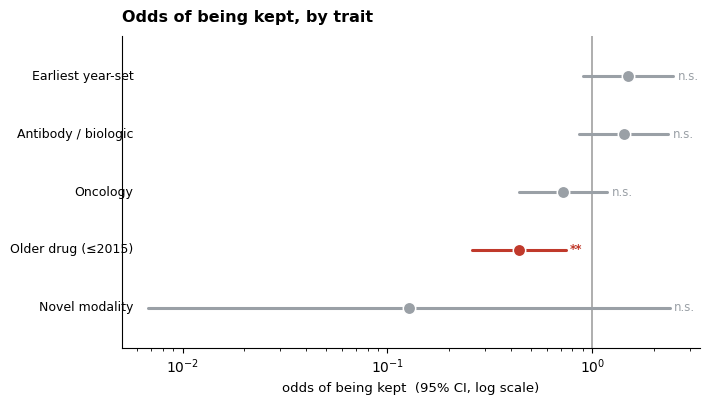

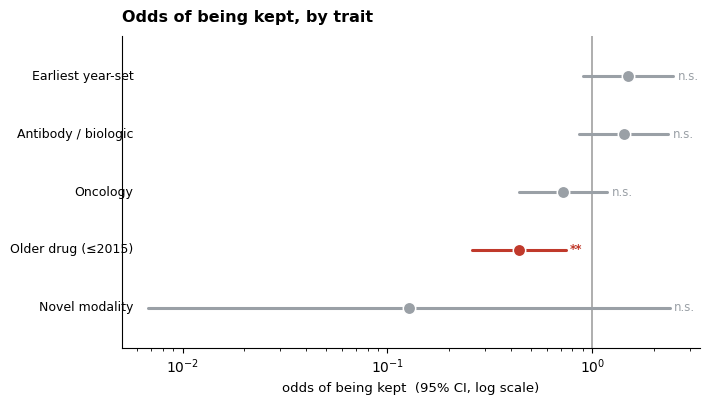

In [4]:
fig = plot_forest(df, 'kept', TRAITS); display(fig)


### 3b · Continuous covariate — kept vs dropped distribution


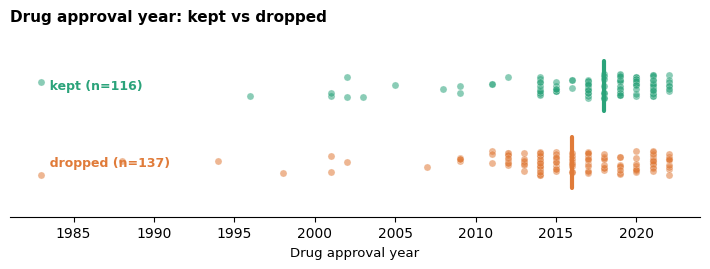

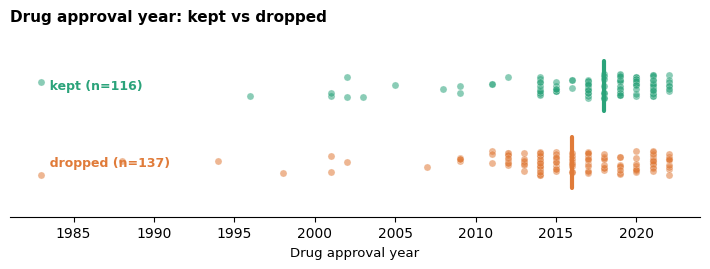

In [5]:
for v in CONT_VARS:
    display(plot_distribution(df, 'kept', v))


### 3c · Composition of kept vs dropped across categorical covariates


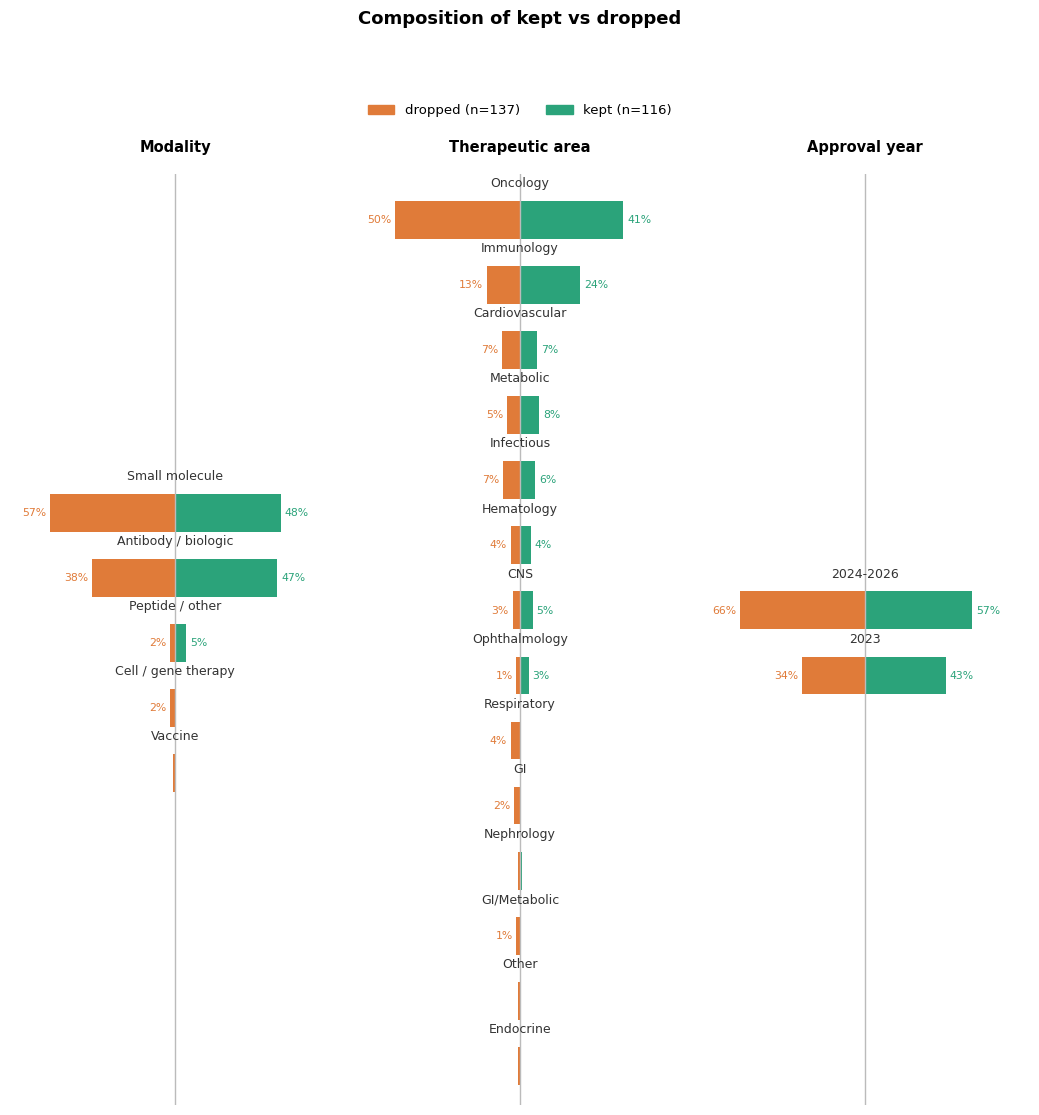

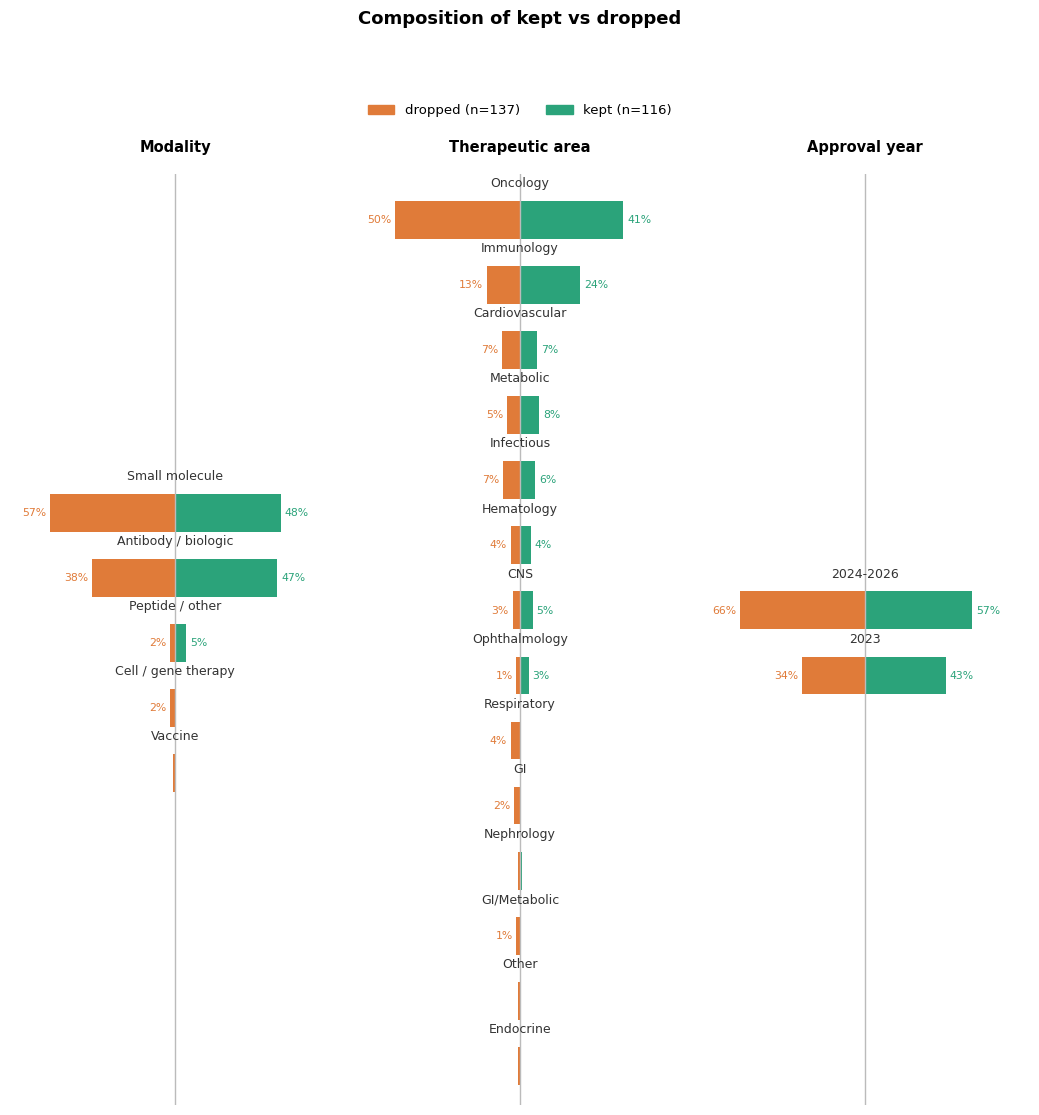

In [6]:
fig = plot_composition(df, 'kept', CAT_VARS); display(fig)
